# The Valley - Datathon EDA IV

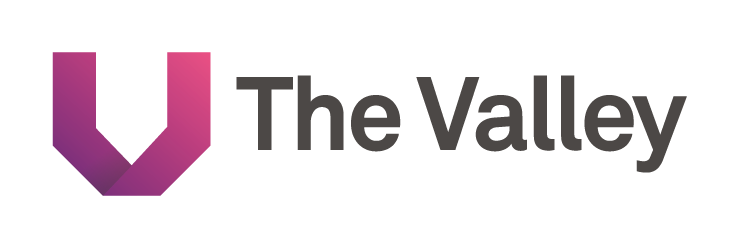

# 1. Lectura de los datos en un dataframe

Vamos a leer los datos de un csv de películas de IMDB

Enlace: (https://raw.githubusercontent.com/ssillerom/modulo_analisis_exploratorio/refs/heads/main/data/IMDB-Movie-Data.csv)

In [1]:
# Cargamos las librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
# Leemos el csv
df_movies = pd.read_csv('https://raw.githubusercontent.com/ssillerom/modulo_analisis_exploratorio/refs/heads/main/data/IMDB-Movie-Data.csv', sep=",")

# 2. Análisis descriptivo del dataframe

In [5]:
# Visualizamos las últimas dos filas
df_movies.tail(2)

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
998,999,Search Party,"Adventure,Comedy",A pair of friends embark on a mission to reuni...,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,5.6,4881,NaN,22.0
999,1000,Nine Lives,"Comedy,Family,Fantasy",A stuffy businessman finds himself trapped ins...,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.3,12435,19.64,11.0


In [6]:
# ¿Cuántas columnas tenemos? ¿Cuáles son?
print("El numero total de columnas es: ", len(df_movies.columns))
print(df_movies.columns)

El numero total de columnas es:  12
Index(['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)',
       'Metascore'],
      dtype='object')


In [5]:
# Devuelve la información de los tipos de las columnas
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


In [6]:
# Nulos por columna
df_movies.isnull().sum()

,0
Rank,0
Title,0
Genre,0
Description,0
Director,0
Actors,0
Year,0
Runtime (Minutes),0
Rating,0
Votes,0


In [7]:
# Estadística básica (media, moda, mediana ...) También que aparezcan las variables categóricas ¿Qué métricas aparecen en el caso de que no sean numéricas?
df_movies.describe(include='all')

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000,1000,1000,1000,1000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
unique,NaN,999,207,1000,644,996,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,The Host,"Action,Adventure,Sci-Fi",A stuffy businessman finds himself trapped ins...,Ridley Scott,"Jennifer Lawrence, Josh Hutcherson, Liam Hemsw...",NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2,50,1,8,2,NaN,NaN,NaN,NaN,NaN,NaN
mean,500.500000,NaN,NaN,NaN,NaN,NaN,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,NaN,NaN,NaN,NaN,NaN,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,NaN,NaN,NaN,NaN,NaN,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,NaN,NaN,NaN,NaN,NaN,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,NaN,NaN,NaN,NaN,NaN,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,NaN,NaN,NaN,NaN,NaN,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000


In [8]:
# Normalizar el nombre de las columnas (evitar espacios, utilizar minúsculas en todas las columnas utilizando list comprehension)
df_movies.rename(columns = {'Runtime (Minutes)' : 'Runtime_in_Minutes', 'Revenue (Millions)': 'Revenue_in_Millions'},
                 inplace = True)
# Utilizando un list comprehension modificamos todas las columnas poniéndolas en minúsculas
df_movies.columns = [column.lower() for column in df_movies.columns]
# Check a los cambios
df_movies.columns

Index(['rank', 'title', 'genre', 'description', 'director', 'actors', 'year',
       'runtime_in_minutes', 'rating', 'votes', 'revenue_in_millions',
       'metascore'],
      dtype='object')

# 3. Gestión de duplicados


In [1]:
# Hemos creado un dataset con duplicados
df_temp = pd.concat([df_movies, df_movies], axis = 0)

NameError: name 'pd' is not defined

In [10]:
# ¿Cuál es el tamaño del nuevo dataset?
df_temp.shape

(2000, 12)

In [ ]:
# ¿Cómo visualizarías si hay duplicados?
df_temp.sort_values(by='title', axis=0, inplace=True)
df_temp.head()

,rank,title,genre,description,director,actors,year,runtime_in_minutes,rating,votes,revenue_in_millions,metascore
507,508,(500) Days of Summer,"Comedy,Drama,Romance",An offbeat romantic comedy about a woman who d...,Marc Webb,"Zooey Deschanel, Joseph Gordon-Levitt, Geoffre...",2009,95,7.7,398972,32.39,76.0
507,508,(500) Days of Summer,"Comedy,Drama,Romance",An offbeat romantic comedy about a woman who d...,Marc Webb,"Zooey Deschanel, Joseph Gordon-Levitt, Geoffre...",2009,95,7.7,398972,32.39,76.0
118,119,10 Cloverfield Lane,"Drama,Horror,Mystery","After getting in a car accident, a woman is he...",Dan Trachtenberg,"John Goodman, Mary Elizabeth Winstead, John Ga...",2016,104,7.2,192968,71.90,76.0
118,119,10 Cloverfield Lane,"Drama,Horror,Mystery","After getting in a car accident, a woman is he...",Dan Trachtenberg,"John Goodman, Mary Elizabeth Winstead, John Ga...",2016,104,7.2,192968,71.90,76.0
696,697,10 Years,"Comedy,Drama,Romance","The night before their high school reunion, a ...",Jamie Linden,"Channing Tatum, Rosario Dawson, Chris Pratt, J...",2011,100,6.1,19636,0.20,NaN


In [12]:
# Elimina los duplicados (explica la decisión que has tomado para eliminarlos)
df_temp.drop_duplicates(subset='rank', keep='first', inplace=True)

In [13]:
# Revisa el dataset de nuevo para asegurarte de que no hay duplicados
df_temp.shape

(1000, 12)

# 4. Filtrar dataframes


In [14]:
# Seleccionamos la película "Split" y las columnas desde "rank" a "actors"
split_loc0 = df_movies.loc[df_movies['title'] == 'Split', 'rank': 'actors']
# Devuelve el resultado
split_loc0

,rank,title,genre,description,director,actors
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar..."


In [15]:
# Devuelve el mismo resultado buscando por índice
split_loc1 = df_movies.iloc[2, 0:6]

In [16]:
# Esto devuelve una serie de pandas pero lo que quiero es un dataframe igual al caso anterior
pd.DataFrame(split_loc1).T

,rank,title,genre,description,director,actors
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar..."


In [17]:
# Devuelve todas las columnas para la película "Suicide Squad"
split_loc2 = df_movies.loc[df_movies['title'] == 'Suicide Squad', :]
split_loc2

,rank,title,genre,description,director,actors,year,runtime_in_minutes,rating,votes,revenue_in_millions,metascore
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


In [18]:
# Seleccionar en un dataframe nuevo solo las columnas que son string
df_movies_str = df_movies.select_dtypes(include=['object'])

In [19]:
# Creamos una columna que sea la duración de la película en horas
df_movies['runtime_in_hours'] = df_movies['runtime_in_minutes'] / 60

In [20]:
# Creamos una nueva columna que agrupe los ingresos en 4 grupos iguales que se llamen ('Low','Medium','High','Very High')
# Dividir en 4 cuartiles
df_movies['revenue_quartile'] = pd.qcut(df_movies['revenue_in_millions'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# Ver la distribución
print(df_movies['revenue_quartile'].value_counts())

revenue_quartile
Low          218
Medium       218
High         218
Very High    218
Name: count, dtype: int64


# 5. Gestión de valores nulos


In [21]:
# Primero creamos una copia del dataframe original
df_movies_cp = df_movies.copy()

In [22]:
# Con el dataframe df_movies elimina todas las filas con nulos
df_movies.dropna(axis = 0 , inplace=True)

In [23]:
# Como df_movies_cp sigue teniendo nulos imputa la media en la columna "revenue_in_millions"
mean_revenue = df_movies_cp.revenue_in_millions.mean()
df_movies_cp.revenue_in_millions.fillna(mean_revenue, inplace=True)

<ipython-input-23-03c1aa13a96d>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_movies_cp.revenue_in_millions.fillna(mean_revenue, inplace=True)


In [24]:
# Ahora imputa la mediana en la columna metascore
median_metascore = df_movies_cp.metascore.median()
df_movies_cp.metascore.fillna(median_metascore, inplace=True)

<ipython-input-24-2c854cfbfbb3>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_movies_cp.metascore.fillna(median_metascore, inplace=True)


In [25]:
# Comprueba que en df_movies_cp no hay nulos
df_movies_cp.isnull().sum()

,0
rank,0
title,0
genre,0
description,0
director,0
actors,0
year,0
runtime_in_minutes,0
rating,0
votes,0


In [26]:
# Seguimos teniendo nulos en la variable que habíamos categorizado anteriormente. Imputamos los nulos con una columna que sea "Desco"
# Agregar la nueva categoría 'Unknown' a las categorías existentes
df_movies_cp['revenue_quartile'] = df_movies_cp['revenue_quartile'].cat.add_categories('Unknown')

In [27]:
# Rellenamos los valores nulos con 'Unknown'
df_movies_cp['revenue_quartile'].fillna('Unknown', inplace=True)

<ipython-input-27-709d6a21561b>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_movies_cp['revenue_quartile'].fillna('Unknown', inplace=True)


In [28]:
# Comprobamos de nuevo
df_movies_cp.isnull().sum()

,0
rank,0
title,0
genre,0
description,0
director,0
actors,0
year,0
runtime_in_minutes,0
rating,0
votes,0


# 6. Agrupaciones

In [29]:
# 1. Película de Acción con mayor rating
top_rated_action = df_movies[df_movies['genre']=='Action'].sort_values(by='rating', ascending=False).head(1)

In [30]:
# 1.1 Películas con mayor rating por género.
top_rated_per_genre = df_movies.loc[df_movies.groupby('genre')['rating'].idxmax()]
top_rated_per_genre[['title', 'genre', 'rating']]

,title,genre,rating
580,Kickboxer: Vengeance,Action,4.9
368,The Amazing Spider-Man,"Action,Adventure",7.0
8,The Lost City of Z,"Action,Adventure,Biography",7.1
33,Deadpool,"Action,Adventure,Comedy",8.0
281,Sherlock Holmes,"Action,Adventure,Crime",7.6
...,...,...,...
541,Limitless,"Mystery,Sci-Fi,Thriller",7.4
138,Shutter Island,"Mystery,Thriller",8.1
616,2307: Winter's Dream,Sci-Fi,4.0
512,The Happening,"Sci-Fi,Thriller",5.0


In [31]:
# 2. Promedio de duración y rating por género (ordenadas por rating descendente)
genre_stats = df_movies.groupby('genre').agg({
    'runtime_in_minutes': 'mean',
    'rating': 'mean'
}).sort_values(by='rating', ascending=False).reset_index()
genre_stats

,genre,runtime_in_minutes,rating
0,"Animation,Drama,Fantasy",106.0,8.600000
1,"Drama,Family,Music",165.0,8.500000
2,"Drama,Western",165.0,8.400000
3,"Adventure,Drama,War",153.0,8.300000
4,"Adventure,Drama,Sci-Fi",156.5,8.300000
...,...,...,...
184,"Action,Fantasy,Thriller",114.0,5.200000
185,"Drama,Horror,Thriller",90.0,5.066667
186,"Sci-Fi,Thriller",91.0,5.000000
187,Action,90.0,4.900000


In [32]:
# 3. Número de películas y promedio de votos por director. Renombra las columnas a 'number_of_movies' y 'average_votes'
director_stats = df_movies.groupby('director').agg({
    'title': 'count',
    'votes': 'mean'
}).rename(columns={'title': 'number_of_movies', 'votes': 'average_votes'}).sort_values(by='number_of_movies', ascending=False).reset_index()
director_stats

,director,number_of_movies,average_votes
0,Ridley Scott,8,260009.250000
1,Paul W.S. Anderson,6,109576.166667
2,Michael Bay,6,284421.833333
3,David Yates,6,338975.666667
4,Danny Boyle,5,276833.400000
...,...,...,...
519,Tomas Alfredson,1,157053.000000
520,Tom Six,1,60655.000000
521,Tom McGrath,1,183926.000000
522,Andrew Jarecki,1,44158.000000


In [33]:
# 4. Año con mayor cantidad de películas
movies_per_year = df_movies['year'].value_counts().reset_index(name='number_of_movies')
movies_per_year

,year,number_of_movies
0,2016,198
1,2015,109
2,2014,93
3,2013,84
4,2012,62
5,2010,57
6,2011,57
7,2008,48
8,2009,45
9,2007,44


In [34]:
# 5. Ingreso total y promedio por año
revenue_stats = df_movies.groupby('year').agg({
    'revenue_in_millions': ['sum', 'mean']
}).reset_index()
revenue_stats.columns = ['year', 'total_revenue', 'average_revenue']
revenue_stats

,year,total_revenue,average_revenue
0,2006,3577.48,87.255610
1,2007,4095.26,93.074091
2,2008,4681.22,97.525417
3,2009,5208.39,115.742000
4,2010,5989.65,105.081579
5,2011,5341.09,93.703333
6,2012,6826.39,110.103065
7,2013,7399.11,88.084643
8,2014,7945.33,85.433656
9,2015,8799.09,80.725596


In [35]:
# 6. Calcular cuánto se desvía el ingreso 'revenue_in_millions' de cada película del ingreso promedio de su año
df_movies['revenue_deviation_year'] = df_movies.groupby('year')['revenue_in_millions'].transform(
    lambda x: x - x.mean()
)

In [36]:
# Sabemos que tenemos películas que forman parte de varios generos, vamos a crear tantas filas como géneros distintos tenga la película
# Nos creamos una copia del dataset
movies_genres = df_movies.copy()

# Separamos los géneros de la lista (separar por ',')
movies_genres['genre'] = movies_genres['genre'].str.split(',')

# Usar explode para dividir las listas en filas
movies_genres = movies_genres.explode('genre').reset_index(drop=True)

In [37]:
movies_genres

,rank,title,genre,description,director,actors,year,runtime_in_minutes,rating,votes,revenue_in_millions,metascore,runtime_in_hours,revenue_quartile,revenue_deviation_year
0,1,Guardians of the Galaxy,Action,A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0,2.016667,Very High,247.696344
1,1,Guardians of the Galaxy,Adventure,A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0,2.016667,Very High,247.696344
2,1,Guardians of the Galaxy,Sci-Fi,A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0,2.016667,Very High,247.696344
3,2,Prometheus,Adventure,"Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0,2.066667,Very High,16.356935
4,2,Prometheus,Mystery,"Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0,2.066667,Very High,16.356935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,998,Step Up 2: The Streets,Music,Romantic sparks occur between two dance studen...,Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,70699,58.01,50.0,1.633333,High,-39.515417
2186,998,Step Up 2: The Streets,Romance,Romantic sparks occur between two dance studen...,Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,70699,58.01,50.0,1.633333,High,-39.515417
2187,1000,Nine Lives,Comedy,A stuffy businessman finds himself trapped ins...,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.3,12435,19.64,11.0,1.450000,Medium,-35.926111
2188,1000,Nine Lives,Family,A stuffy businessman finds himself trapped ins...,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.3,12435,19.64,11.0,1.450000,Medium,-35.926111


# 7. Visualizaciones

## 7.1 Seaborn

<ipython-input-38-a496b56d30c5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_movies, x='year', palette='viridis')


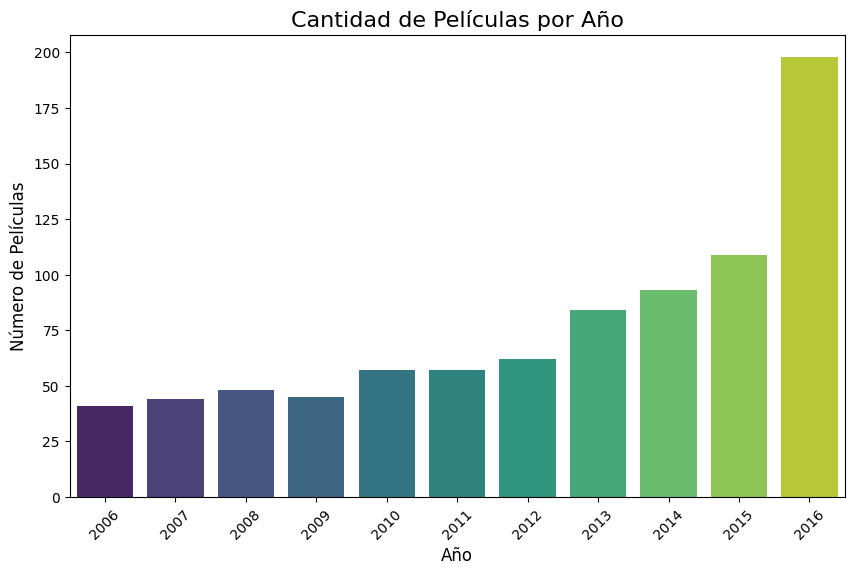

In [38]:
# Número de películas por año
plt.figure(figsize=(10, 6))
sns.countplot(data=df_movies, x='year', palette='viridis')
plt.title('Cantidad de Películas por Año', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Películas', fontsize=12)
plt.xticks(rotation=45)
plt.show()

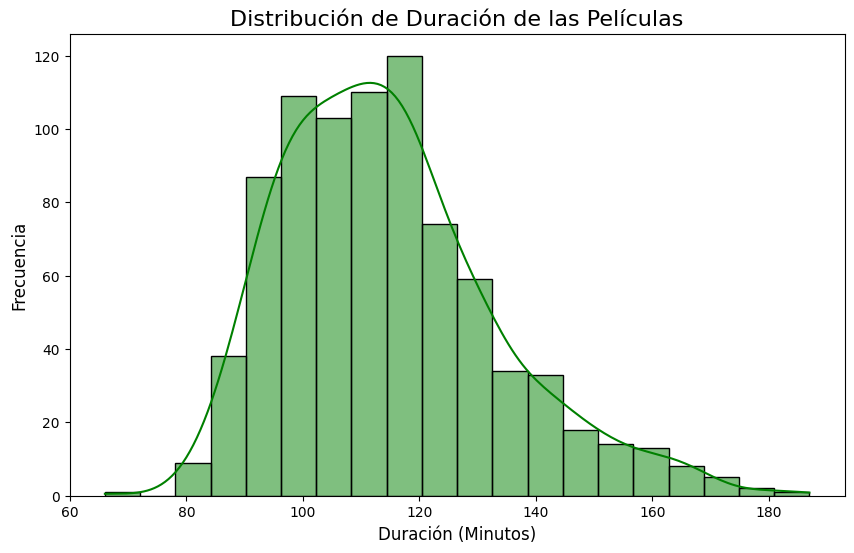

In [39]:
# Cómo se distribuye la duración de las películas
plt.figure(figsize=(10, 6))
sns.histplot(data=df_movies, x='runtime_in_minutes', bins=20, kde=True, color='green')
plt.title('Distribución de Duración de las Películas', fontsize=16)
plt.xlabel('Duración (Minutos)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

<ipython-input-40-6c2c01ffb26f>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_movies, x='runtime_in_minutes', y='rating', palette='cool', alpha=0.7)


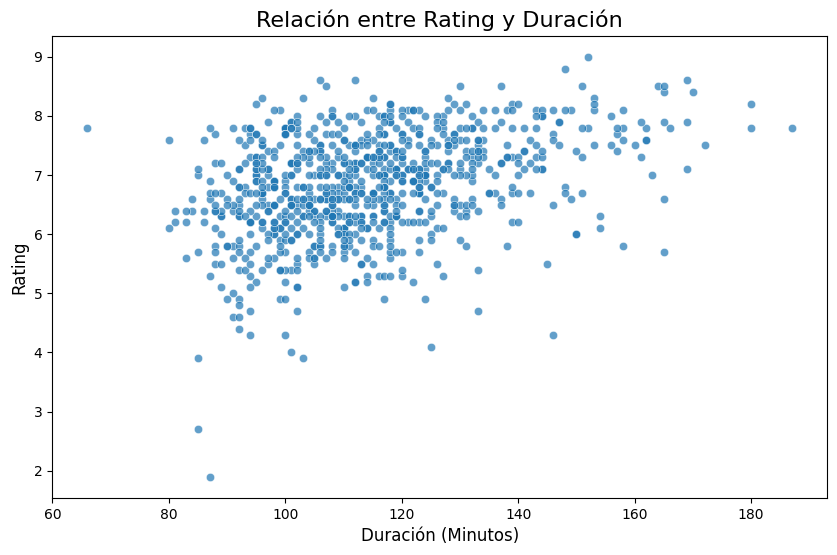

In [40]:
# ¿Existe relación entre rating y duración? ¿Qué gráfico usarías para visualizarlo?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_movies, x='runtime_in_minutes', y='rating', palette='cool', alpha=0.7)
plt.title('Relación entre Rating y Duración', fontsize=16)
plt.xlabel('Duración (Minutos)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

<ipython-input-41-dbd11431507d>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=movies_genres, x='genre', y='rating', palette='coolwarm')


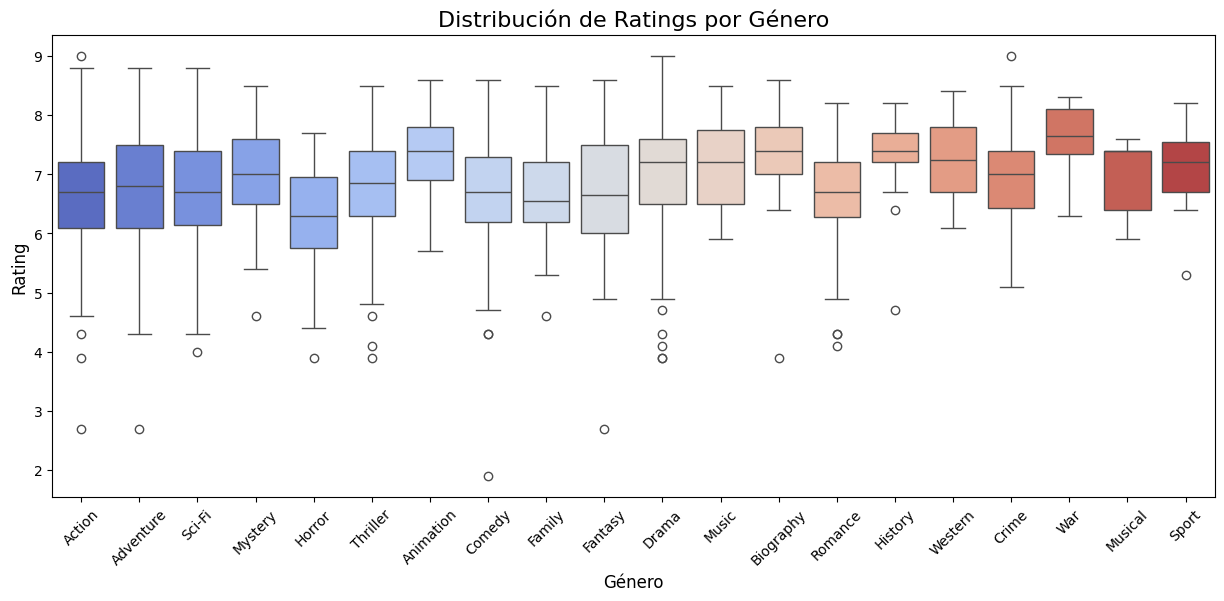

In [41]:
# ¿Hay más dispersión en los ratings en función del género? Usa un boxplot que represente el rating por género (te servirá para visualizar outliers!)
# Usa el dataframe que has generado  donde aparece un único género por fila
plt.figure(figsize=(15, 6))
sns.boxplot(data=movies_genres, x='genre', y='rating', palette='coolwarm')
plt.title('Distribución de Ratings por Género', fontsize=16)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.xticks(rotation=45)
plt.show()

<ipython-input-42-051f7d76591b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=movies_genres, x='genre', y='revenue_in_millions', palette='muted', inner='quartile')


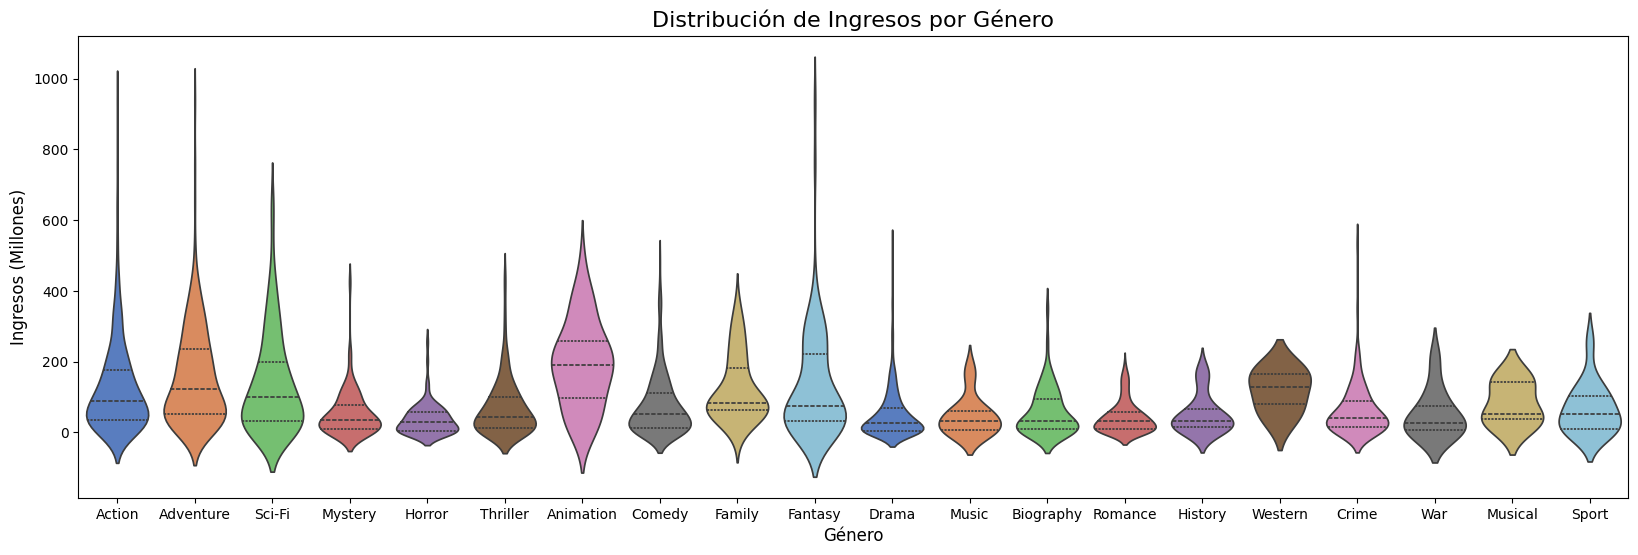

In [42]:
# Ingreso por género
plt.figure(figsize=(20, 6))
sns.violinplot(data=movies_genres, x='genre', y='revenue_in_millions', palette='muted', inner='quartile')
plt.title('Distribución de Ingresos por Género', fontsize=16)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Ingresos (Millones)', fontsize=12)
plt.show()

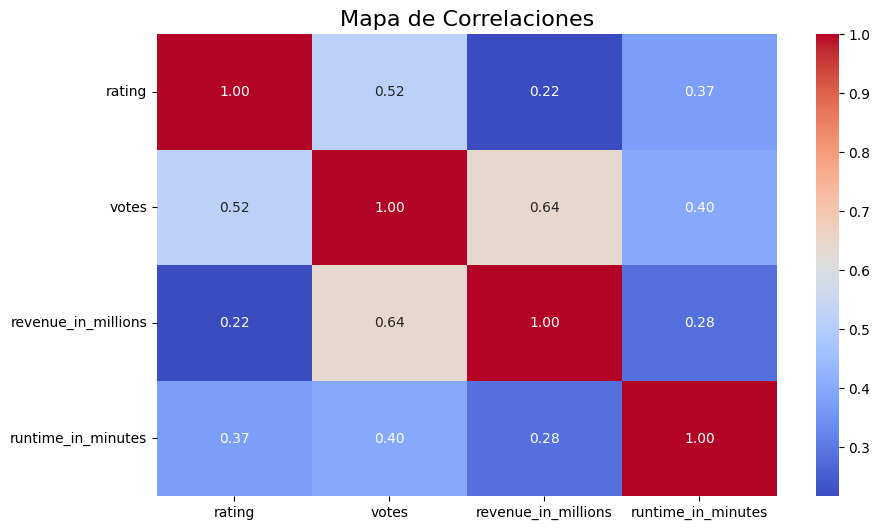

In [43]:
# Devuelve las correlaciones entre las variables numéricas
plt.figure(figsize=(10, 6))
corr_matrix = df_movies[['rating', 'votes', 'revenue_in_millions', 'runtime_in_minutes']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Correlaciones', fontsize=16)
plt.show()

## 7.2 Matplotlib

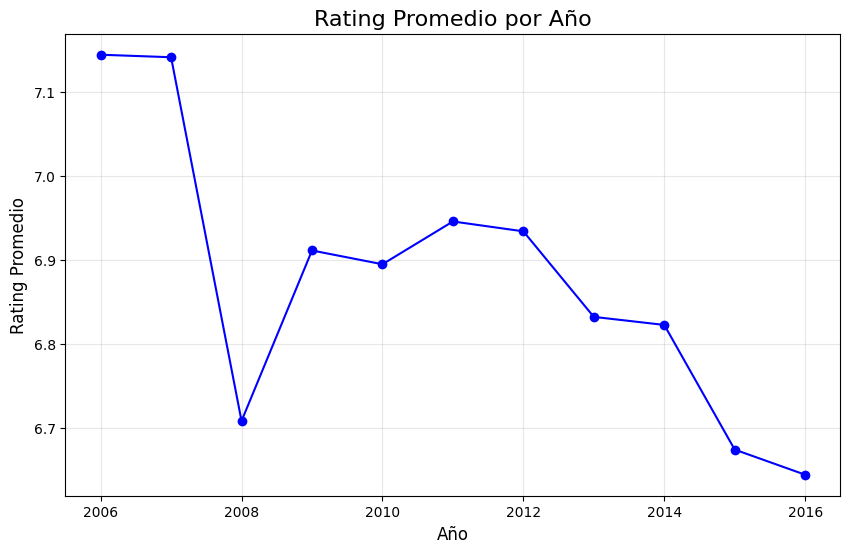

In [44]:
# Rating promedio por año (con matplotlib)
rating_per_year = df_movies.groupby('year')['rating'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(rating_per_year['year'], rating_per_year['rating'], marker='o', color='blue')
plt.title('Rating Promedio por Año', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Rating Promedio', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

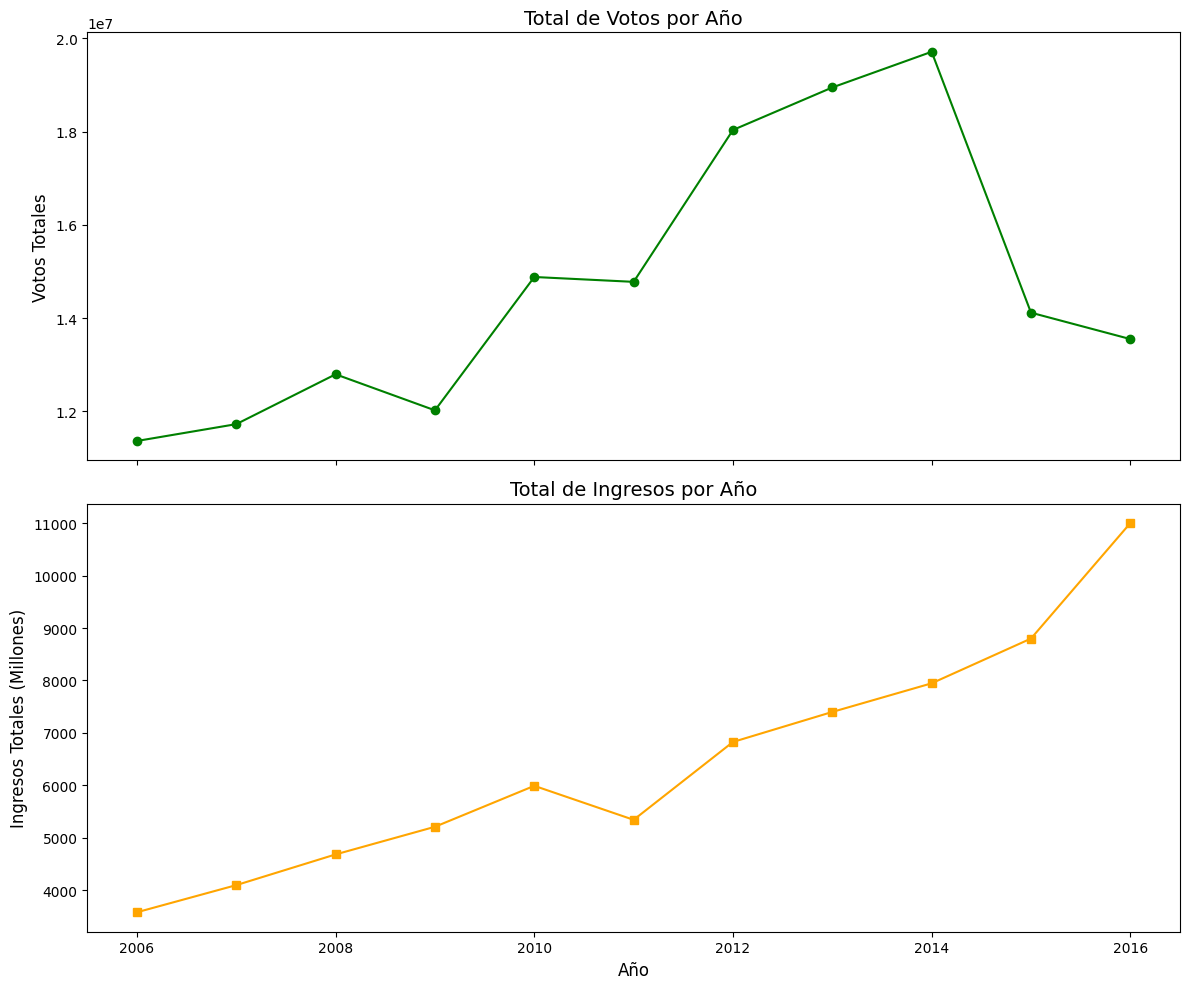

In [45]:
# Representa en el mismo gráfico la evolución de votos por años y los ingresos por años
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Subplot 1: Total de votos por año
votes_per_year = df_movies.groupby('year')['votes'].sum()
axes[0].plot(votes_per_year.index, votes_per_year.values, marker='o', color='green')
axes[0].set_title('Total de Votos por Año', fontsize=14)
axes[0].set_ylabel('Votos Totales', fontsize=12)

# Subplot 2: Total de ingresos por año
revenue_per_year = df_movies.groupby('year')['revenue_in_millions'].sum()
axes[1].plot(revenue_per_year.index, revenue_per_year.values, marker='s', color='orange')
axes[1].set_title('Total de Ingresos por Año', fontsize=14)
axes[1].set_xlabel('Año', fontsize=12)
axes[1].set_ylabel('Ingresos Totales (Millones)', fontsize=12)

plt.tight_layout()
plt.show()

In [46]:
# ¿Serías capaz de juntar los votos, el revenue, el rating y el año? Crea un gráfico de plotly que represente en la x los votos, la y el revenue, que diferencie los años por color y el tamaño de los puntos sea por rating
# Crear el scatterplot interactivo
fig = px.scatter(
    df_movies,
    x='votes',
    y='revenue_in_millions',
    size='rating',  # Tamaño del punto basado en el rating
    color='year',  # Colorear por año
    hover_name='title',  # Mostrar título de la película al pasar el cursor
    title='Relación entre Votos, Ingresos y Rating',
    labels={'Votes': 'Número de Votos', 'Revenue (Millions)': 'Ingresos (Millones)', 'Rating': 'Rating'}
)

# Ajustar layout
fig.update_layout(
    xaxis=dict(title='Número de Votos'),
    yaxis=dict(title='Ingresos (Millones)'),
    legend=dict(title='Año')
)

# Mostrar el gráfico
fig.show()
